#📌 Extracción

In [23]:

import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [24]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

df = pd.concat([df.drop(['customer','phone','internet','account'], axis=1),
                customer, phone, internet, account], axis=1)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [25]:
print("Columnas del dataset:")
print(df.columns)
print("\n")

print("Información del dataset:")
df.info()
print("\n")

print("Ejemplo de un registro:")
print(df.iloc[0])
print("\n")

print("Distribución de Churn:")
print(df['Churn'].value_counts())
print("\n")

columnas_relevantes = ['customer', 'phone', 'internet', 'account', 'Churn']

print("Columnas relevantes para el análisis de evasión:")
print(columnas_relevantes)

Columnas del dataset:
Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='str')


Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   str    
 1   Churn             7267 non-null   str    
 2   gender            7267 non-null   str    
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   str    
 5   Dependents        7267 non-null   str    
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   str   

In [26]:
print("Valores ausentes por columna:")
print(df.isnull().sum())
print("\n")


print("Tipos de datos del dataset:")
print(df.dtypes)
print("\n")


print("Valores únicos en Churn:")
print(df['Churn'].unique())
print("\n")


df_temp = df.astype(str) 
duplicados = df_temp.duplicated().sum()

print("Cantidad de registros duplicados:", duplicados)

del df_temp

Valores ausentes por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


Tipos de datos del dataset:
customerID              str
Churn                   str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract         

In [27]:
df = df.loc[~df.astype(str).duplicated()].copy()

print("Valores nulos después de eliminar duplicados:")
print(df.isnull().sum())
print("\n")

if 'Charges.Total' in df.columns:
    df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

df = df.fillna(0)

print("Tipos de datos después de la corrección:")
print(df.dtypes)

Valores nulos después de eliminar duplicados:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


Tipos de datos después de la corrección:
customerID              str
Churn                   str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies 

In [28]:
df = df.loc[:, ~df.columns.duplicated()]

df['Charges.Monthly'] = pd.to_numeric(df['Charges.Monthly'], errors='coerce')

df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

df[['Charges.Monthly', 'Cuentas_Diarias']].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [29]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

columnas_binarias = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in columnas_binarias:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

df[['Churn']].head()

,Churn
0,0.0
1,0.0
2,1.0
3,1.0
4,1.0


#📊 Carga y análisis

In [30]:
print("Estadísticas descriptivas del dataset:")
print(df.describe())

print("\n")

print("Media:")
print(df.mean(numeric_only=True))

print("\nMediana:")
print(df.median(numeric_only=True))

print("\nDesviación estándar:")
print(df.std(numeric_only=True))

Estadísticas descriptivas del dataset:
             Churn  SeniorCitizen      Partner   Dependents       tenure  \
count  7043.000000    7267.000000  7267.000000  7267.000000  7267.000000   
mean      0.265370       0.162653     0.484106     0.300124    32.346498   
std       0.441561       0.369074     0.499782     0.458343    24.571773   
min       0.000000       0.000000     0.000000     0.000000     0.000000   
25%       0.000000       0.000000     0.000000     0.000000     9.000000   
50%       0.000000       0.000000     0.000000     0.000000    29.000000   
75%       1.000000       0.000000     1.000000     1.000000    55.000000   
max       1.000000       1.000000     1.000000     1.000000    72.000000   

       PhoneService  PaperlessBilling  Charges.Monthly  Charges.Total  \
count   7267.000000       7267.000000      7267.000000    7267.000000   
mean       0.902711          0.593230        64.720098    2277.182035   
std        0.296371          0.491265        30.129572   

Valores únicos en Churn:
[ 0.  1. nan]

Conteo de Churn:
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64


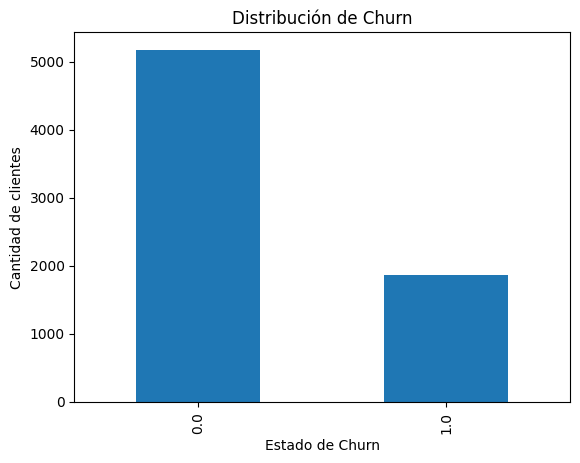

In [31]:
print("Valores únicos en Churn:")
print(df['Churn'].unique())

churn_counts = df['Churn'].value_counts()

print("\nConteo de Churn:")
print(churn_counts)

if len(churn_counts) > 0:
    plt.figure()
    churn_counts.plot(kind='bar')

    plt.title("Distribución de Churn")
    plt.xlabel("Estado de Churn")
    plt.ylabel("Cantidad de clientes")

    plt.show()
else:
    print("\n⚠ No hay datos válidos en la columna Churn para graficar.")


Distribución de Churn por gender:
Churn         0.0        1.0
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


<Figure size 640x480 with 0 Axes>

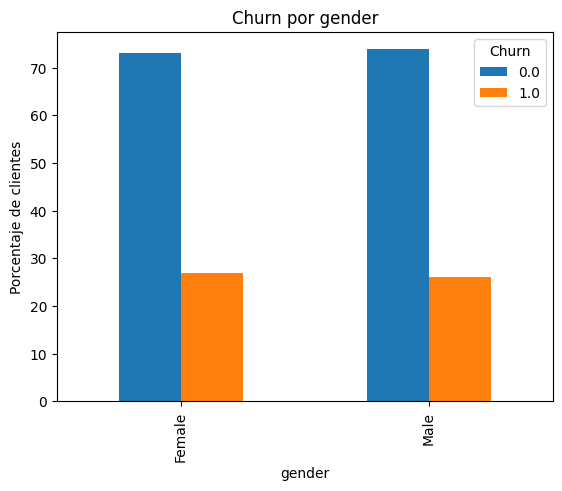


Distribución de Churn por Contract:
Churn                 0.0        1.0
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


<Figure size 640x480 with 0 Axes>

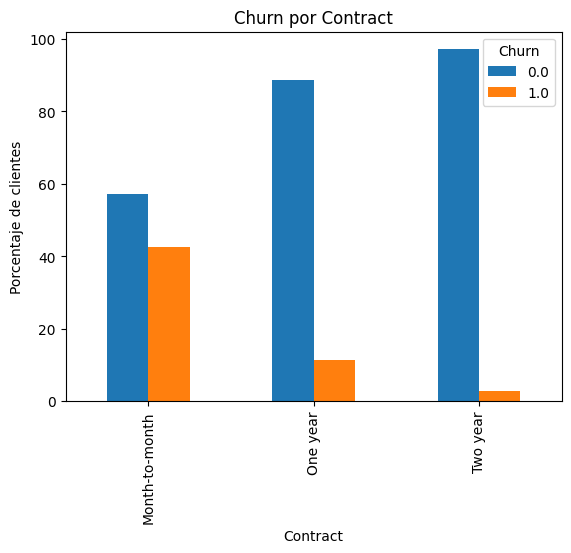


Distribución de Churn por PaymentMethod:
Churn                            0.0        1.0
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


<Figure size 640x480 with 0 Axes>

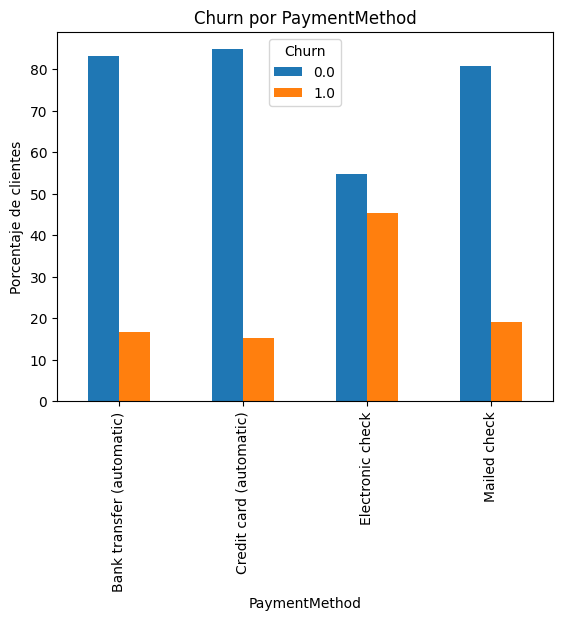

In [32]:
categorical_vars = ['gender', 'Contract', 'PaymentMethod']

for var in categorical_vars:
    
    churn_table = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    
    print(f"\nDistribución de Churn por {var}:")
    print(churn_table)

    plt.figure()
    churn_table.plot(kind='bar')

    plt.title(f"Churn por {var}")
    plt.xlabel(var)
    plt.ylabel("Porcentaje de clientes")
    
    plt.show()

<Figure size 640x480 with 0 Axes>

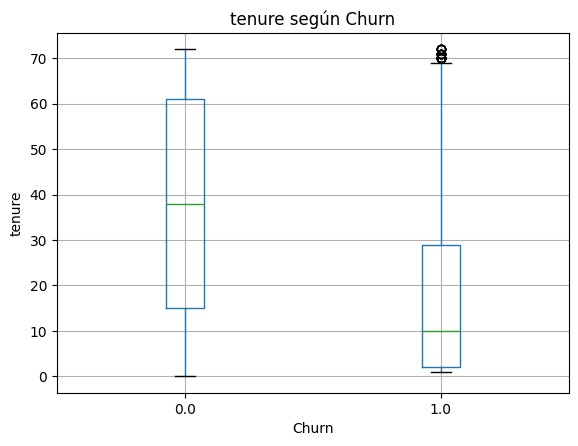

<Figure size 640x480 with 0 Axes>

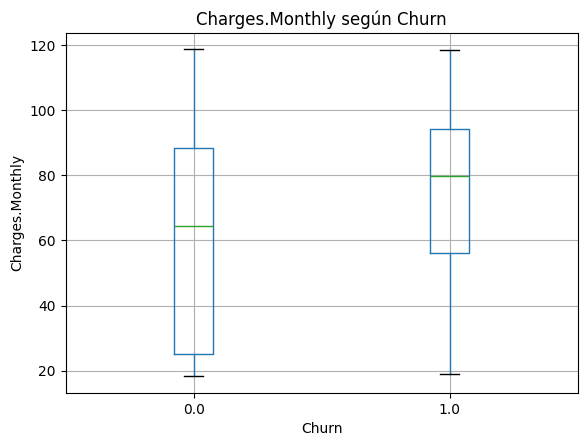

<Figure size 640x480 with 0 Axes>

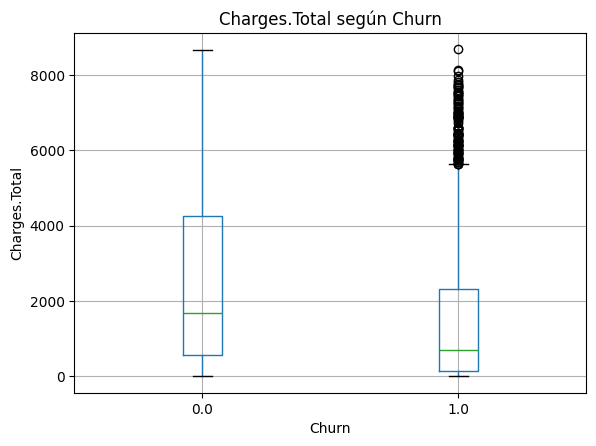

<Figure size 640x480 with 0 Axes>

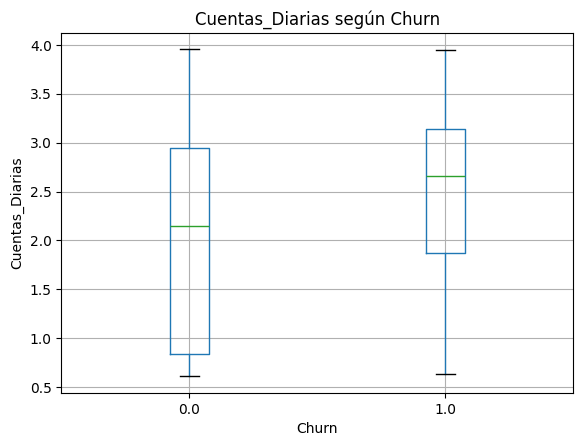

In [33]:
numeric_vars = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

for var in numeric_vars:
    
    plt.figure()
    
    df.boxplot(column=var, by='Churn')
    
    plt.title(f"{var} según Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(var)
    
    plt.show()

#📄Informe final

Informe de Análisis de Evasión de Clientes (Churn)
Introducción

El objetivo de este análisis es entender mejor el problema de evasión de clientes (Churn) en Telecom X. La evasión ocurre cuando un cliente decide cancelar el servicio, lo que representa una pérdida importante para la empresa.

A partir de los datos disponibles, se busca identificar patrones en el comportamiento de los clientes para entender qué factores podrían estar relacionados con la cancelación del servicio.

Limpieza y Tratamiento de Datos

Primero se cargaron los datos desde un archivo JSON utilizando Pandas. Como el dataset tenía información anidada, fue necesario desanidar algunas columnas como customer, phone, internet y account para convertirlas en columnas normales dentro del DataFrame.

Después se revisó la calidad de los datos, verificando:

valores nulos

tipos de datos

registros duplicados

Durante este proceso se eliminaron duplicados, se corrigieron algunos tipos de datos y se transformaron variables categóricas en valores numéricos para facilitar el análisis.

También se creó una nueva variable llamada Cuentas_Diarias, calculada a partir del cargo mensual dividido entre 30 días, con el objetivo de tener una estimación del gasto diario de los clientes.

Análisis Exploratorio de Datos

En esta etapa se realizaron algunos análisis para entender mejor los datos.

Primero se calcularon estadísticas descriptivas como media, mediana y desviación estándar para observar el comportamiento general de las variables numéricas.

Luego se analizó la distribución de Churn, utilizando un gráfico de barras que muestra la cantidad de clientes que permanecen en el servicio frente a los que cancelaron.

También se exploró la relación entre la evasión y algunas variables categóricas, como el género, el tipo de contrato y el método de pago. Para esto se utilizaron gráficos que muestran el porcentaje de churn dentro de cada categoría.

Finalmente, se compararon algunas variables numéricas como el tiempo de permanencia (tenure) y los cargos del servicio utilizando diagramas de caja, lo que permitió observar diferencias entre los clientes que cancelaron y los que continúan con el servicio.

Conclusiones e Insights

A partir del análisis se pueden observar algunos patrones interesantes.

Por ejemplo, los clientes con contratos mensuales parecen tener una mayor tendencia a cancelar el servicio en comparación con los que tienen contratos de mayor duración.

También se observa que los clientes con menos tiempo en la empresa tienen mayor probabilidad de abandonar el servicio.

Además, algunas diferencias en los métodos de pago podrían estar relacionadas con la evasión de clientes.

Estos resultados ayudan a tener una mejor idea de qué factores pueden influir en el churn.

Recomendaciones

Con base en el análisis realizado, se podrían considerar algunas acciones para reducir la evasión de clientes:

Incentivar contratos de mayor duración para aumentar la permanencia de los clientes.

Implementar estrategias de retención temprana para clientes nuevos.

Analizar con más detalle los métodos de pago asociados con mayor churn.

Crear programas de fidelización para mejorar la relación con los clientes.

Este tipo de análisis puede servir como base para futuros modelos predictivos de churn, que permitan anticipar qué clientes podrían cancelar el servicio.